# Product Recommendation System — 01 Exploratory Data Analysis

A **collaborative-filtering** recommender for an e-commerce store, built on the UCI *Online Retail* dataset. The signal is **implicit**: how many units of each product a customer purchased — there are no star ratings. We recommend new products from purchase patterns and evaluate by ranking quality (Precision@k / Recall@k); RMSE does not apply to implicit data.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
%matplotlib inline
import utils
buys=utils.load_interactions(); names=utils.load_items()
print('customer-product pairs:',buys.shape,'| customers:',buys.user.nunique(),'| products:',buys.item.nunique())
buys.head()

customer-product pairs: (168090, 3) | customers: 4281 | products: 800


,user,item,weight
0,12346.0,23166,74215
1,12347.0,20719,40
2,12347.0,21035,6
3,12347.0,21154,10
4,12347.0,21731,72


## 1. Purchase-quantity distribution

Quantities are highly skewed (bulk buyers), so we log-compress them into a confidence weight.

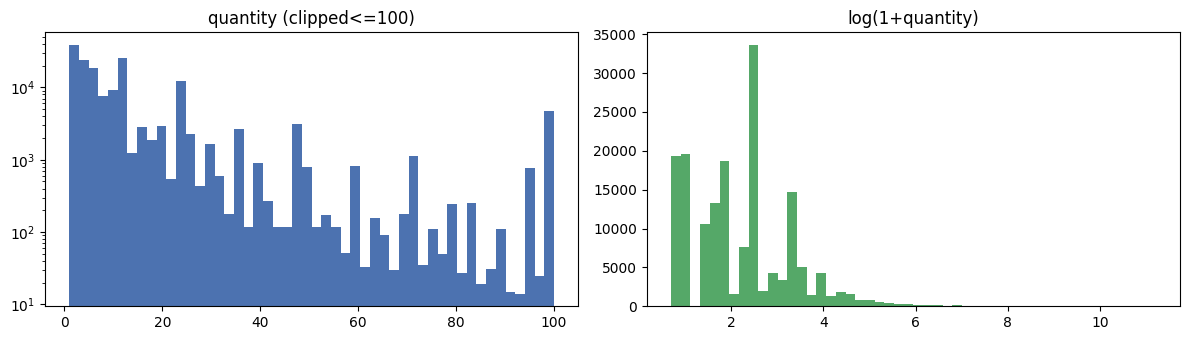

count    168090.0
mean         21.7
std         212.2
min           1.0
25%           3.0
50%           8.0
75%          16.0
max       74215.0


In [2]:
fig,ax=plt.subplots(1,2,figsize=(12,3.5))
ax[0].hist(buys['weight'].clip(upper=100),bins=50,color='#4c72b0'); ax[0].set_title('quantity (clipped<=100)'); ax[0].set_yscale('log')
ax[1].hist(np.log1p(buys['weight']),bins=50,color='#55a868'); ax[1].set_title('log(1+quantity)')
plt.tight_layout(); plt.show()
print(buys['weight'].describe().round(1).to_string())

## 2. Activity per customer / per product

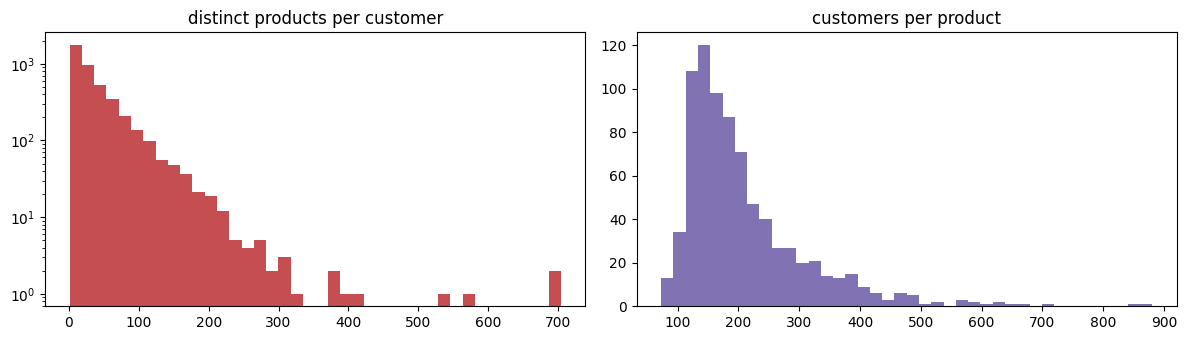

products per customer: median 24 max 704
customers per product: median 179 max 881


In [3]:
ppc=buys.groupby('user').size(); ppp=buys.groupby('item').size()
fig,ax=plt.subplots(1,2,figsize=(12,3.5))
ax[0].hist(ppc,bins=40,color='#c44e52'); ax[0].set_title('distinct products per customer'); ax[0].set_yscale('log')
ax[1].hist(ppp,bins=40,color='#8172b3'); ax[1].set_title('customers per product')
plt.tight_layout(); plt.show()
print('products per customer: median %d max %d'%(ppc.median(),ppc.max())); print('customers per product: median %d max %d'%(ppp.median(),ppp.max()))

## 3. Sparsity

In [4]:
nu,ni=buys.user.nunique(),buys.item.nunique(); d=len(buys)/(nu*ni)
print(f'{nu} customers x {ni} products = {nu*ni:,} cells; {len(buys):,} purchase pairs')
print('density: %.3f%% (sparsity %.3f%%)'%(100*d,100*(1-d)))

4281 customers x 800 products = 3,424,800 cells; 168,090 purchase pairs
density: 4.908% (sparsity 95.092%)


## 4. Best-selling products (by total units)

In [5]:
top=buys.groupby('item')['weight'].sum().sort_values(ascending=False).head(10)
top.index=top.index.map(names)
print(top.to_string())

item
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
POPCORN HOLDER                        49183
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36782
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
PACK OF 12 LONDON TISSUES             25345


## 5. Summary

- The cleaned subsample (top-800 products) has **4,281 customers, 800 products, ~168k customer-product pairs** — the purchase matrix is **~93% sparse**.
- Quantities are heavily skewed by wholesale buyers; log1p compression stabilises them.
- Each customer buys a few dozen distinct products. Notebooks 02–03 build the implicit matrix and compare item-CF vs matrix factorization on ranking quality.